# Understanding Feature Engineering

Feature engineering is a crucial step in the machine learning pipeline. In simple terms, it's the process of using domain knowledge to extract or transform raw data into features that better represent the underlying problem to the predictive models. Think of it as preparing and enhancing your ingredients before cooking a meal – the better the ingredients, the better the final dish!

The goal is to improve the performance of machine learning algorithms by providing them with more meaningful and informative data. It often involves creativity and an understanding of both the data and the problem you're trying to solve.

## Key Parts of Feature Engineering

Feature engineering isn't a single task, but rather a collection of techniques. Here are some common categories:

*   **Creation of New Features:** Combining existing features, extracting parts of a feature (e.g., month from a date), or creating aggregate statistics.
*   **Transformation of Existing Features:** Changing the scale or distribution of numerical features (e.g., standardization, normalization, log transformation), or encoding categorical features into numerical representations.
*   **Handling Missing Values:** Deciding how to deal with incomplete data, whether by imputation (filling in missing values) or removal.
*   **Feature Selection/Extraction:** Identifying the most relevant features and removing redundant or less important ones, or using techniques like PCA to reduce dimensionality.
*   **Discretization/Binning:** Converting continuous numerical features into categorical ones by grouping values into bins.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Feature Scaling: Standardization and Normalization

Feature scaling is a method used to standardize the range of independent variables or features of data. In data processing, it is also known as data normalization and is generally performed during the data preprocessing step.

In [2]:
# I am creating some dummy data so i can perform normalization and standardization on it then we will compare to it
# Set seed for reproducibility
np.random.seed(42)

# 1. Generate 100 synthetic e-commerce products
n_samples = 100

# Normal distribution for weights (mean 2kg, std 0.5kg)
weights = np.random.normal(loc=2.0, scale=0.5, size=n_samples)
# Inject a couple of heavy outliers to see how scalers handle them
weights[0] = 18.5
weights[1] = 15.0

# Prices loosely correlated with weight (in INR)
prices = weights * 400 + np.random.normal(loc=200, scale=100, size=n_samples)

# Ordinal categories for packaging
sizes = np.random.choice(['Small', 'Medium', 'Large', 'Extra Large'], size=n_samples)

# Create the DataFrame
df = pd.DataFrame({
    'Weight_kg': weights,
    'Price_INR': prices,
    'Package_Size': sizes
})

print("Original Dataset (First 5 rows):")
display(df.head())

Original Dataset (First 5 rows):


,Weight_kg,Price_INR,Package_Size
0,18.500000,7458.462926,Medium
1,15.000000,6157.935468,Medium
2,2.323844,1095.266256,Small
3,2.761515,1224.378244,Extra Large
4,1.882923,937.040754,Small


In [3]:
df.describe()

,Weight_kg,Price_INR
count,100.000000,100.000000
mean,2.241284,1098.744256
std,2.146278,847.261272
min,0.690127,503.720059
25%,1.699547,863.846536
50%,1.953085,970.943476
75%,2.260295,1104.505783
max,18.500000,7458.462926


In [4]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

### Standardization (Z-score normalization)

Standardization transforms data to have a mean of 0 and a standard deviation of 1. It's particularly useful when the data has outliers or when the algorithm assumes a Gaussian distribution.

**Formula:**

$X_{\text{standardized}} = \frac{X - \mu}{\sigma}$

Where:
*   $X$ is the original feature value.
*   $\mu$ is the mean of the feature.
*   $\sigma$ is the standard deviation of the feature.



### Normalization (Min-Max scaling)

Normalization scales data to a fixed range, usually between 0 and 1. This is beneficial for algorithms that don't assume any distribution of the data and are sensitive to the magnitude of the input features, like neural networks.

**Formula:**

$X_{\text{normalized}} = \frac{X - X_{\text{min}}}{X_{\text{max}} - X_{\text{min}}}$

Where:
*   $X$ is the original feature value.
*   $X_{\text{min}}$ is the minimum value of the feature.
*   $X_{\text{max}}$ is the maximum value of the feature.

In [7]:
# i am applying label encoding on my categorical data
size_mapping = {'Small': 0, 'Medium': 1, 'Large': 2, 'Extra Large': 3}
df['size_encoded'] = df['Package_Size'].map(size_mapping)

In [6]:
# scaling: standardization vs normalization
standard_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()

features_to_scale = ['Weight_kg', 'Price_INR']

In [8]:
# applying standardization
standardized_data = standard_scaler.fit_transform(df[features_to_scale])
df['Weight_Standardized'] = standardized_data[:, 0]
df['Price_Standardized'] = standardized_data[:, 1]

In [9]:
# appltying normalization
normalized_data = min_max_scaler.fit_transform(df[features_to_scale])
df['Weight_Normalized'] = normalized_data[:, 0]
df['Price_Normalized'] = normalized_data[:, 1]

In [10]:
print("\nData after Engineering (First 5 rows):")
display(df.head())


Data after Engineering (First 5 rows):


,Weight_kg,Price_INR,Package_Size,size_encoded,Weight_Standardized,Price_Standardized,Weight_Normalized,Price_Normalized
0,18.500000,7458.462926,Medium,1,7.613471,7.544022,1.000000,1.000000
1,15.000000,6157.935468,Medium,1,5.974525,6.001311,0.803480,0.813001
2,2.323844,1095.266256,Small,0,0.038660,-0.004126,0.091731,0.085057
3,2.761515,1224.378244,Extra Large,3,0.243608,0.149029,0.116306,0.103621
4,1.882923,937.040754,Small,0,-0.167810,-0.191816,0.066974,0.062306


# now i will try to visualize this data to see how my data is looking after visualization

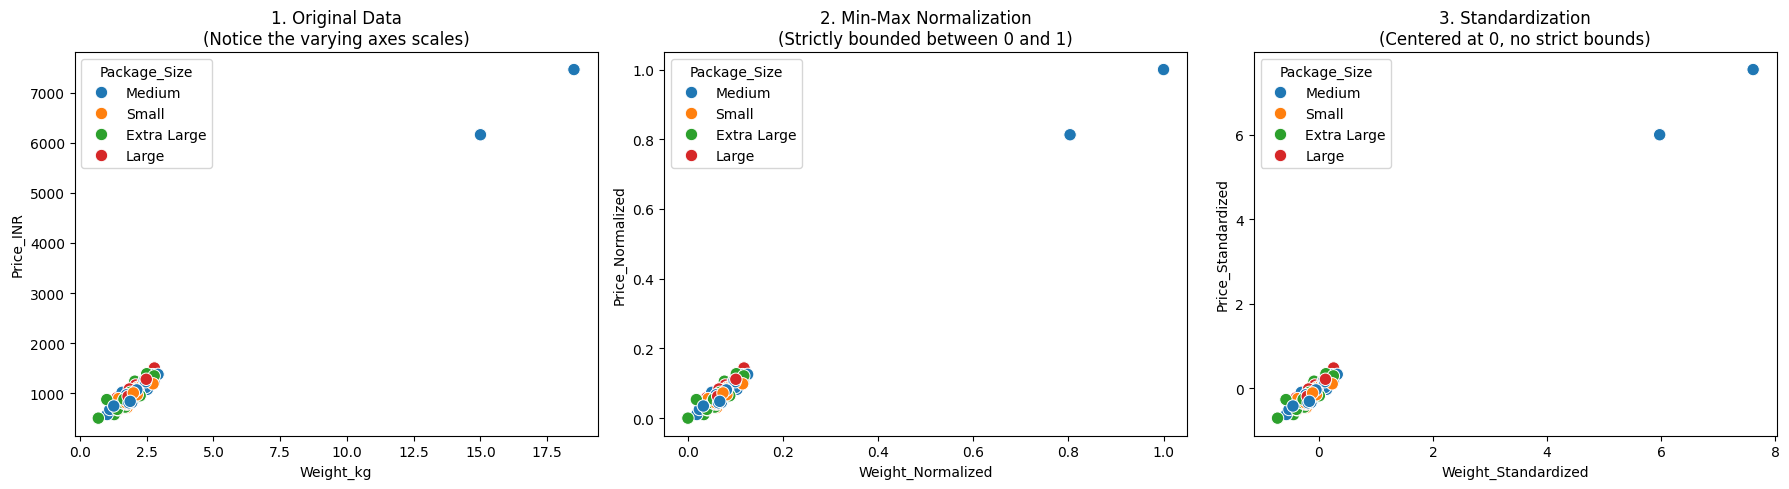

In [12]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Original Data
sns.scatterplot(x='Weight_kg', y='Price_INR', hue='Package_Size', data=df, ax=axes[0], s=80)
axes[0].set_title("1. Original Data\n(Notice the varying axes scales)")

# Plot 2: Min-Max Normalization
sns.scatterplot(x='Weight_Normalized', y='Price_Normalized', hue='Package_Size', data=df, ax=axes[1], s=80)
axes[1].set_title("2. Min-Max Normalization\n(Strictly bounded between 0 and 1)")

# Plot 3: Standardization
sns.scatterplot(x='Weight_Standardized', y='Price_Standardized', hue='Package_Size', data=df, ax=axes[2], s=80)
axes[2].set_title("3. Standardization\n(Centered at 0, no strict bounds)")

plt.tight_layout()
plt.show()

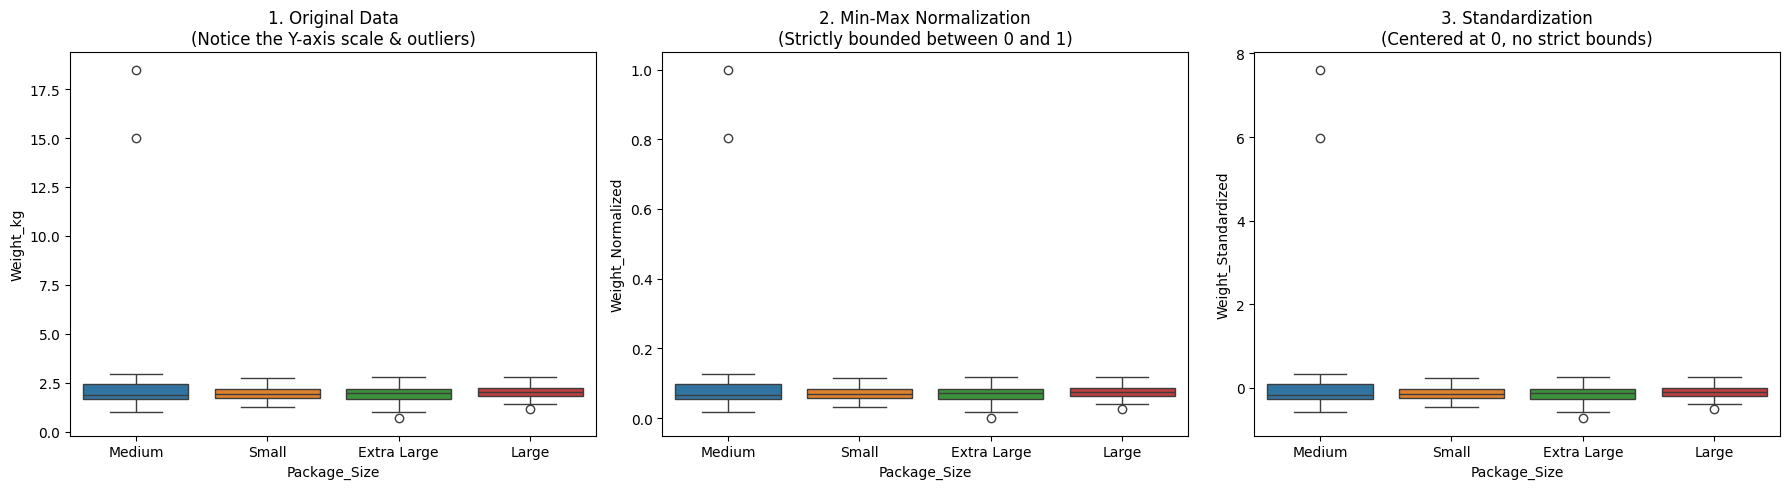

In [13]:
# 4. Visualization (Using Boxplots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Original Data
# We plot the categorical Package_Size on the X-axis, and the numerical Weight on the Y-axis
sns.boxplot(x='Package_Size', y='Weight_kg', data=df, ax=axes[0], hue='Package_Size', legend=False)
axes[0].set_title("1. Original Data\n(Notice the Y-axis scale & outliers)")

# Plot 2: Min-Max Normalization
sns.boxplot(x='Package_Size', y='Weight_Normalized', data=df, ax=axes[1], hue='Package_Size', legend=False)
axes[1].set_title("2. Min-Max Normalization\n(Strictly bounded between 0 and 1)")

# Plot 3: Standardization
sns.boxplot(x='Package_Size', y='Weight_Standardized', data=df, ax=axes[2], hue='Package_Size', legend=False)
axes[2].set_title("3. Standardization\n(Centered at 0, no strict bounds)")

plt.tight_layout()
plt.show()

In [ ]:
# finally i want to show the guys who are here watching this file a great resource so they can feel more
url_to_some_other_guy_repo = "https://github.com/campusx-official/100-days-of-machine-learning/blob/main/day24-standardization/day24.ipynb"